In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("data/game_of_thrones.csv")
df.head(10)

,name,allegiance,season,episode,location,killer,killers_house,method,death_no
0,Waymar Royce,Night's Watch,1,1,Beyond the Wall,White Walker,NaN,Ice sword,1
1,Gared,Night's Watch,1,1,Beyond the Wall,White Walker,NaN,Ice sword,2
2,Will,Night's Watch,1,1,Winterfell,Ned Stark,House Stark,Sword,3
3,Stag,NaN,1,1,Winterfell,Direwolf,NaN,Teeth,4
4,Direwolf,NaN,1,1,Winterfell,Stag,NaN,Antler,5
5,Jon Arryn,House Arryn,1,1,King's Landing,Lysa Arryn,House Arryn,Poison,6
6,Dothraki man,Dothraki,1,1,Pentos,Dothraki man,Dothraki,Arakh,7
7,Catspaw assassin,NaN,1,2,Winterfell,Summer,House Stark,Teeth,8
8,Mycah,Smallfolk,1,2,Kingsroad,"Sandor ""the Hound"" Clegane",House Lannister,Sword,9
9,Lady,House Stark,1,2,Kingsroad,Ned Stark,House Stark,Knife,10


Contiene todos los datos de las muertes de juego de tronos.
name: Nombre del asesinado.
season: Temporada.
method: Como ha muerto.
death_no: El numero de muerte en la serie.
location: Lugar del asesinato.
killer: Asesino.


Informacion de nuestro DF. string:"Desconocido", number: 0

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           2224 non-null   str  
 1   allegiance     1792 non-null   str  
 2   season         2224 non-null   int64
 3   episode        2224 non-null   int64
 4   location       2224 non-null   str  
 5   killer         2214 non-null   str  
 6   killers_house  2194 non-null   str  
 7   method         2224 non-null   str  
 8   death_no       2224 non-null   int64
dtypes: int64(3), str(6)
memory usage: 156.5 KB


In [6]:
df = df.fillna({"allegiance": "Desconocido", 
                "killer_house": "Desconocido",
                "killer": "Desconocido",})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           2224 non-null   str  
 1   allegiance     2224 non-null   str  
 2   season         2224 non-null   int64
 3   episode        2224 non-null   int64
 4   location       2224 non-null   str  
 5   killer         2224 non-null   str  
 6   killers_house  2194 non-null   str  
 7   method         2224 non-null   str  
 8   death_no       2224 non-null   int64
dtypes: int64(3), str(6)
memory usage: 156.5 KB


Podemos hacer de todo, por ejemplo, quedarnos con las cosas de la Temporada 1.

In [17]:
df_temp1 = df[df["season"] == 1]
muertes_temp1 = df_temp1.shape[0]
muertes_totales = df.shape[0]
impacto_temp1 = round(muertes_temp1/muertes_totales * 100,2)
impacto_temp1
df_temp2 = df[df["season"] == 2]
muertes_temp2 = df_temp2.shape[0]
muertes_totales = df.shape[0]
impacto_temp2 = round(muertes_temp2/muertes_totales * 100,2)
impacto_temp2
df_temp3 = df[df["season"] == 3]
muertes_temp3 = df_temp3.shape[0]
muertes_totales = df.shape[0]
impacto_temp3 = round(muertes_temp3/muertes_totales * 100,2)
impacto_temp3


3.87

In [18]:
data = {
    "Temporadas": ["Temporada 1", "Temporada 2", "Temporada 3"],
    "Impacto": [impacto_temp1, impacto_temp2, impacto_temp3],
}
df_impacto = pd.DataFrame.from_dict(data)
df_impacto

,Temporadas,Impacto
0,Temporada 1,2.61
1,Temporada 2,5.85
2,Temporada 3,3.87


<Axes: xlabel='Temporadas'>

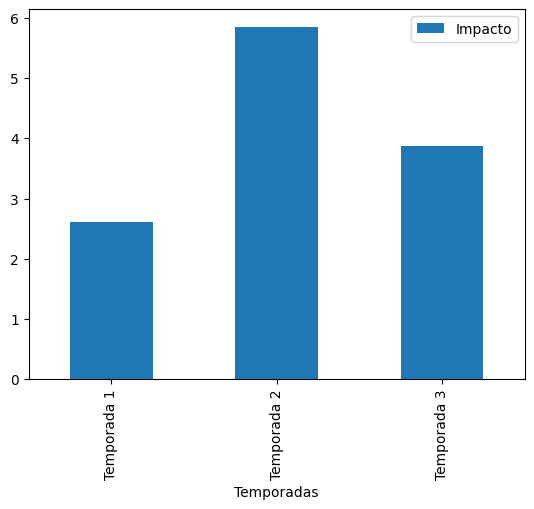

In [19]:
df_impacto.plot(kind="bar", x="Temporadas", y="Impacto")

In [20]:
df_season = df.groupby("season")["name"]
df_season.describe()

,count,unique,top,freq
season,,,,
1,58,37,Stark soldier,12
2,130,40,Baratheon of Dragonstone soldier,55
3,86,30,Stark soldier,27
4,170,43,Wildling,61
5,158,36,Sons of the Harpy agent,67
6,396,53,King's Landing Noble,138
7,334,20,Lannister soldier,204
8,892,29,Golden Company soldier,374


Me gustaria saber el nombre del asesino y su numero de muertes.

In [ ]:
df_killer = df.groupby("killer")["death_no"].agg(["count"])
df_killer

,count
killer,
Accident,1
Aemon Targaryen,1
Alliser Thorne,3
Amory Lorch,1
Arthur Dayne,3
...,...
Wildling giant,2
Wun Wun,3
Yara Greyjoy,11


Quiero saber cuantas muertes ha realizado Daenerys Targarian

In [22]:
df_killer[df_killer["killer" == "Daenerys Targaryen"]]

KeyError: False